# Spatial single-cell type annotation

This tutorial demonstrates the HBC1 cell-type annotation workflow. PhenoMap first annotates generated spatial single-cell expression using reference-derived marker genes. Three supervised transfer methods, CellTypist, Tangram and Ingest, are then combined into an ensemble label that is used as the reference label for downstream evaluation.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score
from scipy.stats import pearsonr


def find_repo_root():
    current = Path.cwd().resolve()
    for path in (current, *current.parents):
        if (path / "README.md").exists() and (path / "step1").exists():
            return path
    raise RuntimeError("Please run this notebook from inside the PhenoMap repository.")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from phenomap import load_tutorial_data
from phenomap.cell_annotation import (
    DEFAULT_MARKER_GENES,
    annotate_cells,
    build_ensemble_labels,
    run_celltypist_transfer,
    run_ingest_transfer,
    run_tangram_transfer,
    select_marker_genes,
)
from step1.utils.plotting import (
    plot_expression_annotation_heatmaps,
    plot_major_class_metric_bars,
    plot_spatial_cell_type_maps,
    set_plot_style,
)

set_plot_style()
tutorial_data = load_tutorial_data(repository_root=REPO_ROOT)
TUTORIAL_DIR = REPO_ROOT / "outputs" / "02_spatial_cell_type_annotation"
TUTORIAL_DIR.mkdir(parents=True, exist_ok=True)

GENERATED_EXPRESSION = tutorial_data.path("hbc1.generated_expression")
MEASURED_EXPRESSION = tutorial_data.path("hbc1.measured_expression")
FEATURE_PATH = tutorial_data.path("hbc1.cell_features")
PHENOMAP_CELL_TYPES = tutorial_data.path("hbc1.phenomap_cell_types")
REFERENCE_CELL_TYPES = tutorial_data.path("hbc1.reference_cell_types")
MEASURED_CELL_TYPES = tutorial_data.path("hbc1.measured_cell_types")

CELL_TYPES = [
    "Cancer_epithelial", "Stromal", "T_cells", "Myeloid",
    "Normal_epithelial", "Endothelial", "B_cells", "Unknown",
]
CELL_COLORS = {
    "Cancer_epithelial": "#DE5253", "Stromal": "#989898",
    "T_cells": "#56B356", "Myeloid": "#45CBD8",
    "Normal_epithelial": "#E892CE", "Endothelial": "#FF983E",
    "B_cells": "#4C92C3", "Unknown": "#333333",
}


def canonical_label_table(table):
    table = table.copy()
    categorical = [
        column for column in table.columns
        if table[column].dropna().astype(str).isin(CELL_TYPES).mean() > 0.95
    ]
    if not categorical:
        raise ValueError("No cell-type label column was found in the configured annotation table.")
    label_column = categorical[-1]
    remaining_text = [
        column for column in table.select_dtypes(include=["object", "string"]).columns
        if column != label_column
    ]
    rename = {label_column: "cell_type"}
    if remaining_text:
        rename[remaining_text[-1]] = "decision_level"
    return table.rename(columns=rename)


print("PhenoMap repository and annotation resources configured.")


PhenoMap repository and annotation resources configured.


## 1. Derive marker genes from the reference atlas

Marker genes are selected from the Wu et al. breast cancer single-cell reference and restricted to genes detected in the measured HBC1 spatial single-cell matrix. The public marker-selection API caches the resulting dictionary automatically.


In [2]:
marker_cache = tutorial_data.path("hbc1.marker_cache")
if marker_cache.exists():
    marker_dict = json.loads(marker_cache.read_text(encoding="utf-8"))
    print("Reused cached marker genes.")
else:
    marker_dict = select_marker_genes(
        tutorial_data.require("hbc1.reference_marker_table"),
        tutorial_data.require("hbc1.measured_expression"),
        candidate_markers=DEFAULT_MARKER_GENES,
    )
    marker_cache.parent.mkdir(parents=True, exist_ok=True)
    marker_cache.write_text(json.dumps(marker_dict, indent=2), encoding="utf-8")
    print("Selected and cached marker genes.")

marker_summary = pd.DataFrame({
    "cell_type": list(marker_dict),
    "n_markers": [len(value) for value in marker_dict.values()],
    "markers": [", ".join(value) for value in marker_dict.values()],
})
marker_summary.style.hide(axis="index")


Reused cached marker genes.


cell_type,n_markers,markers
B_cells,6,"MZB1, MS4A1, CD83, BANK1, ITM2C, SEC11C"
Cancer_epithelial,10,"ELF3, S100A14, CLDN4, KRT7, KRT8, AGR3, ANKRD30A, EPCAM, CCND1, CD9"
Endothelial,10,"RAMP2, VWF, AQP1, PECAM1, CLEC14A, CD93, TCF4, PDK4, STC1, MMRN2"
Myeloid,9,"LYZ, C1QA, C1QC, TYROBP, APOC1, FCER1G, AIF1, CD68, CD14"
Normal_epithelial,8,"KRT14, KRT15, PTN, TACSTD2, KRT5, SFRP1, DST, ACTG2"
Stromal,10,"LUM, ACTA2, POSTN, CCDC80, SFRP4, PTGDS, MMP2, FBLN1, CXCL12, MYH11"
T_cells,10,"CCL5, IL7R, CD3E, CXCR4, CD69, CD3D, GZMA, PTPRC, DUSP2, TRAC"


## 2. Annotate PhenoMap-generated single-cell expression

PhenoMap scores each cell against the reference-derived marker sets and assigns the cell type with the highest marker score. A cached annotation is loaded when available; otherwise the public annotation API regenerates it.


In [3]:
if PHENOMAP_CELL_TYPES.exists():
    phenomap_labels = pd.read_csv(PHENOMAP_CELL_TYPES, index_col=0)
    print("Reused cached PhenoMap cell types.")
else:
    phenomap_labels = annotate_cells(tutorial_data.require("hbc1.generated_expression"), marker_dict)
    PHENOMAP_CELL_TYPES.parent.mkdir(parents=True, exist_ok=True)
    phenomap_labels.to_csv(PHENOMAP_CELL_TYPES)
    print("Generated and cached PhenoMap cell types.")
phenomap_labels.index = phenomap_labels.index.astype(str)
print(f"Annotated cells: {len(phenomap_labels):,}")
cell_type_counts = (
    phenomap_labels["cell_type"].value_counts()
    .reindex(CELL_TYPES).fillna(0).astype(int)
    .rename_axis("cell_type").reset_index(name="n_cells")
)
cell_type_counts.style.hide(axis="index")


Reused cached PhenoMap cell types.
Annotated cells: 126,438


cell_type,n_cells
Cancer_epithelial,47080
Stromal,25241
T_cells,22918
Myeloid,9630
Normal_epithelial,8348
Endothelial,10768
B_cells,1924
Unknown,529


## 3. Build the ensemble reference label

CellTypist, Tangram and Ingest independently transfer labels from the reference atlas to measured HBC1 expression. Their cached predictions are combined by the public ensemble API; optional regeneration dependencies are listed in `requirements-annotation.txt`.


In [4]:
transfer_paths = {
    "celltypist": tutorial_data.path("hbc1.celltypist_probabilities"),
    "tangram": tutorial_data.path("hbc1.tangram_probabilities"),
    "ingest": tutorial_data.path("hbc1.ingest_labels"),
}
missing_transfers = [name for name, path in transfer_paths.items() if not path.exists()]
if missing_transfers:
    import scanpy as sc
    reference_atlas = sc.read_h5ad(tutorial_data.require("hbc1.reference_atlas"))
    gene_list = tutorial_data.require("hbc1.gene_list")
    if "celltypist" in missing_transfers:
        result = run_celltypist_transfer(MEASURED_EXPRESSION, reference_atlas, gene_list=gene_list)
        transfer_paths["celltypist"].parent.mkdir(parents=True, exist_ok=True)
        result.to_csv(transfer_paths["celltypist"])
    if "tangram" in missing_transfers:
        result = run_tangram_transfer(MEASURED_EXPRESSION, reference_atlas, gene_list=gene_list)
        transfer_paths["tangram"].parent.mkdir(parents=True, exist_ok=True)
        result.to_csv(transfer_paths["tangram"])
    if "ingest" in missing_transfers:
        result = run_ingest_transfer(MEASURED_EXPRESSION, reference_atlas, gene_list=gene_list)
        transfer_paths["ingest"].parent.mkdir(parents=True, exist_ok=True)
        result.to_csv(transfer_paths["ingest"])
    print("Generated and cached missing reference-transfer labels.")
else:
    print("Reused cached reference-transfer labels.")

if REFERENCE_CELL_TYPES.exists():
    gt = canonical_label_table(pd.read_csv(REFERENCE_CELL_TYPES, index_col=0))
    print("Reused cached ensemble reference labels.")
else:
    tangram = pd.read_csv(transfer_paths["tangram"], index_col=0)
    celltypist = pd.read_csv(transfer_paths["celltypist"], index_col=0)
    ingest = pd.read_csv(transfer_paths["ingest"], index_col=0)
    gt = build_ensemble_labels(tangram, celltypist, ingest)
    REFERENCE_CELL_TYPES.parent.mkdir(parents=True, exist_ok=True)
    gt.to_csv(REFERENCE_CELL_TYPES)
    print("Built and cached ensemble reference labels.")

gt.index = gt.index.astype(str)
print(f"Reference-labelled cells: {len(gt):,}")
decision_counts = (
    gt["decision_level"].value_counts()
    .rename_axis("decision_level").reset_index(name="n_cells")
)
decision_counts.style.hide(axis="index")


Reused cached reference-transfer labels.


Reused cached ensemble reference labels.
Reference-labelled cells: 125,766


decision_level,n_cells
1_Consensus,80693
2_Majority_CT_IG,26317
2_Majority_TG_IG,6561
2_Majority_TG_CT,6111
3_LowProb_IG_Fallback,2748
3_HighProb_TG_Wins,2350
3_HighProb_CT_Wins,986


## 4. Align labels and inspect cell-type composition

All downstream comparisons use the intersection of PhenoMap-annotated cells and ensemble-labelled cells.

In [5]:
common_cells = phenomap_labels.index.intersection(gt.index)
phenomap_aligned = phenomap_labels.loc[common_cells].copy()
gt_aligned = gt.loc[common_cells].copy()

label_table = pd.DataFrame({
    "PhenoMap": phenomap_aligned["cell_type"].value_counts(),
    "Ground truth": gt_aligned["cell_type"].value_counts(),
}).reindex(CELL_TYPES).fillna(0).astype(int)
prop_table = label_table.div(label_table.sum(axis=0), axis=1)

print(f"Aligned cells: {len(common_cells):,}")
composition_summary = prop_table.rename_axis("cell_type").reset_index()
composition_summary.round(4).style.hide(axis="index")


Aligned cells: 125,766


cell_type,PhenoMap,Ground truth
Cancer_epithelial,0.373500,0.436700
Stromal,0.200400,0.177200
T_cells,0.181100,0.187600
Myeloid,0.076400,0.090600
Normal_epithelial,0.066300,0.032500
Endothelial,0.085200,0.052000
B_cells,0.014800,0.023400
Unknown,0.002400,0.000000


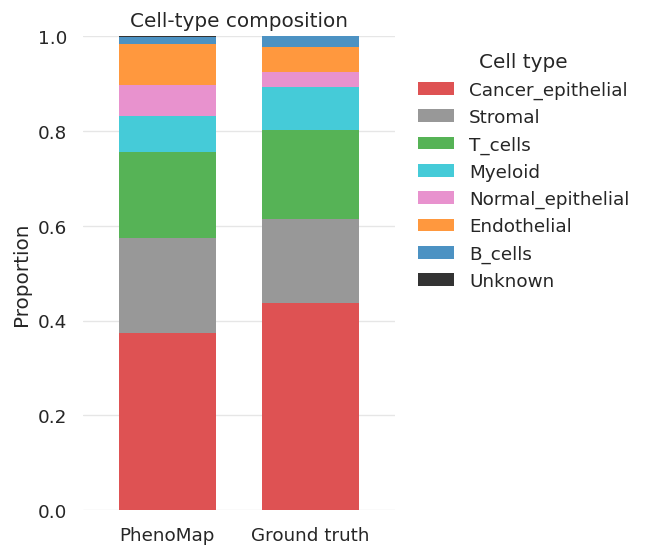

Saved: hbc1_composition_phenomap_vs_groundtruth.png


In [6]:
fig, ax = plt.subplots(figsize=(5.6, 4.8))
prop_table.T.plot(
    kind="bar", stacked=True, color=[CELL_COLORS[c] for c in CELL_TYPES],
    width=0.68, edgecolor="none", ax=ax,
)
ax.set(xlabel="", ylabel="Proportion", title="Cell-type composition")
ax.set_ylim(0, 1)
ax.yaxis.grid(True, color="#e6e6e6", linewidth=0.8)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.legend(title="Cell type", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.setp(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
composition_path = TUTORIAL_DIR / "hbc1_composition_phenomap_vs_groundtruth.png"
fig.savefig(composition_path, bbox_inches="tight")
plt.show()
print(f"Saved: {composition_path.name}")

## 5. Visualize spatial annotations

For a lightweight tutorial view, cell centroids are read from the Step 1 feature HDF5 file and colored by label. The same public plotting API can also render the labels over an H&E background.

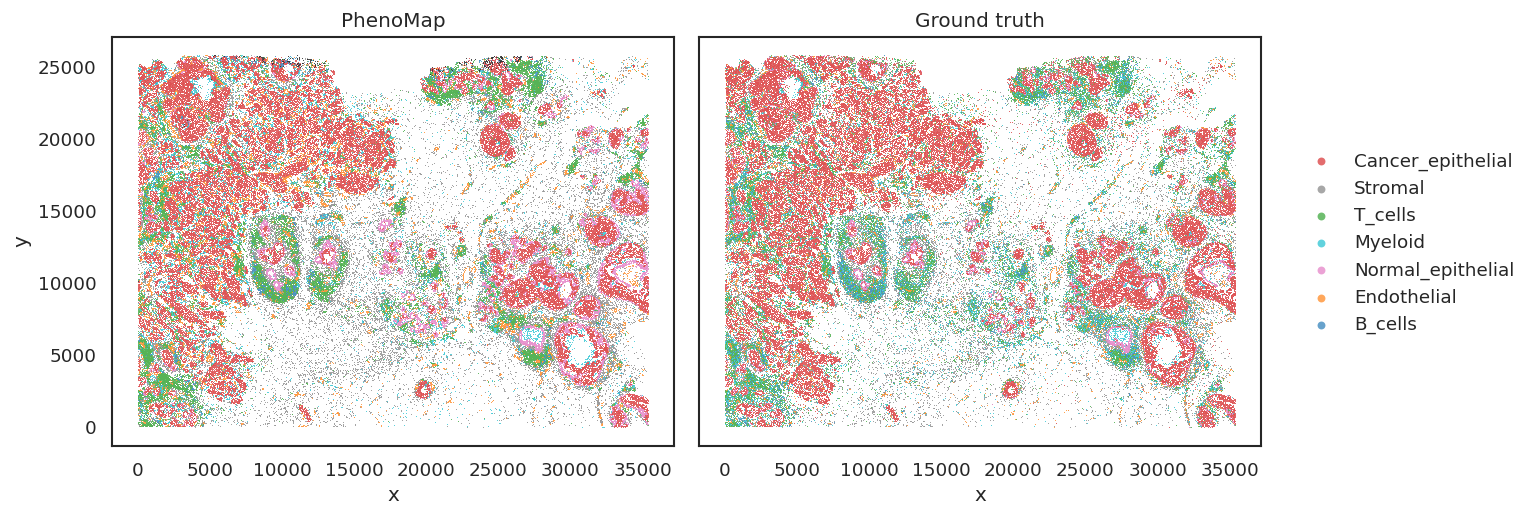

Cells shown per panel: 125,766
Saved: hbc1_spatial_cell_type_maps.png


In [7]:
metadata = pd.read_hdf(tutorial_data.require("hbc1.cell_features"), key="metadata")
metadata.index = metadata.index.astype(str)
meta_common = metadata.loc[metadata.index.intersection(common_cells)].copy()

map_path = plot_spatial_cell_type_maps(
    metadata=meta_common,
    label_series_by_panel={
        "PhenoMap": phenomap_aligned.loc[meta_common.index, "cell_type"],
        "Ground truth": gt_aligned.loc[meta_common.index, "cell_type"],
    },
    cell_types=CELL_TYPES,
    cell_colors=CELL_COLORS,
    output_path=TUTORIAL_DIR / "hbc1_spatial_cell_type_maps.png",
)
print(f"Cells shown per panel: {len(meta_common):,}")
print(f"Saved: {Path(map_path).name}")


## 6. Expression heatmaps stratified by annotated cell type

The heatmaps below show marker-gene expression across cells ordered by their annotated cell type. The ground-truth panel uses the measured Xenium expression matrix and labels produced from Xenium genes; the PhenoMap panel uses the generated expression matrix and labels produced from PhenoMap-predicted genes.

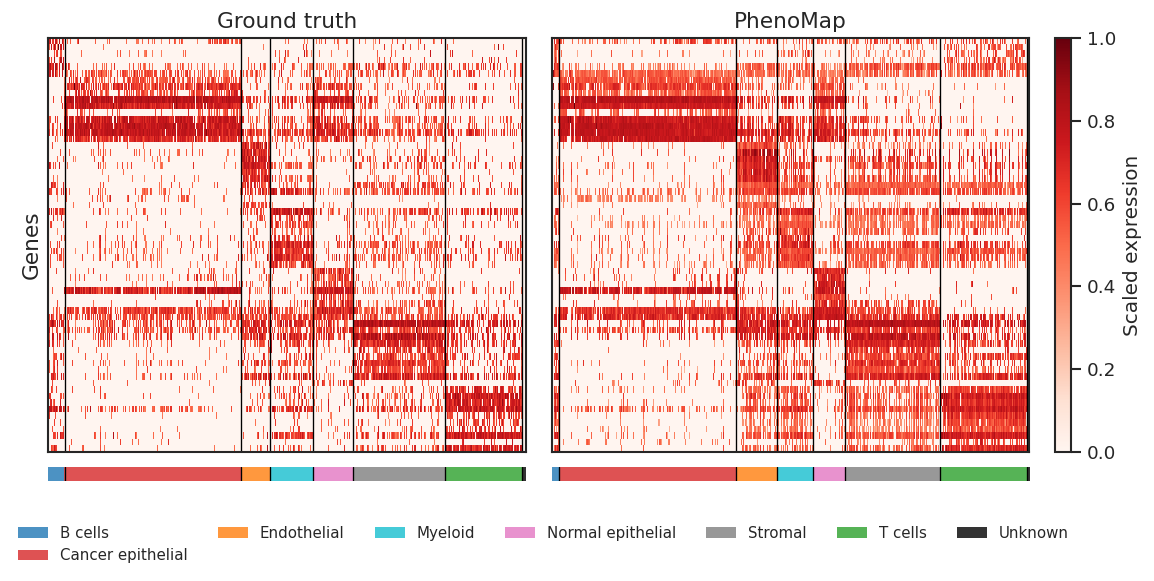

Marker genes shown: 63
Ground-truth cells: 126,438
PhenoMap cells:         126,438
Saved: hbc1_expression_annotation_heatmaps.png


In [8]:
marker_genes = list(dict.fromkeys(gene for genes in marker_dict.values() for gene in genes))


def read_marker_expression(path):
    columns = pd.read_csv(path, nrows=0).columns.tolist()
    available = [gene for gene in marker_genes if gene in columns]
    return pd.read_csv(path, index_col=0, usecols=[columns[0], *available])


true_expression = read_marker_expression(tutorial_data.require("hbc1.measured_expression"))
pred_expression = read_marker_expression(tutorial_data.require("hbc1.generated_expression"))
true_annotation = canonical_label_table(pd.read_csv(tutorial_data.require("hbc1.measured_cell_types"), index_col=0))
pred_annotation = canonical_label_table(pd.read_csv(tutorial_data.require("hbc1.phenomap_cell_types"), index_col=0))
for table in [true_expression, pred_expression, true_annotation, pred_annotation]:
    table.index = table.index.astype(str)

heatmap_info = plot_expression_annotation_heatmaps(
    true_expr=true_expression,
    pred_expr=pred_expression,
    true_annotation=true_annotation,
    pred_annotation=pred_annotation,
    marker_dict=marker_dict,
    cell_colors=CELL_COLORS,
    output_path=TUTORIAL_DIR / "hbc1_expression_annotation_heatmaps.png",
)
print(f"Marker genes shown: {len(heatmap_info['marker_genes'])}")
print(f"Ground-truth cells: {heatmap_info['ground_truth_cells']:,}")
print(f"PhenoMap cells:         {heatmap_info['phenomap_cells']:,}")
print(f"Saved: {Path(heatmap_info['path']).name}")


## 7. Quantify agreement with the ensemble label

Agreement with the ensemble label is summarized by major cell class. F1-score is computed from hard major-class labels, and Spatial PCC measures the correlation between each ensemble one-hot class map and the PhenoMap marker-score probability for the same class.

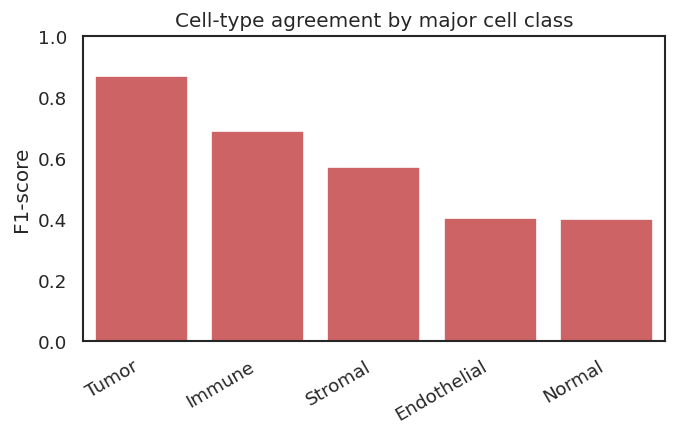

Saved: hbc1_major_class_f1.png


major_class,f1_score
Tumor,0.869100
Immune,0.687900
Stromal,0.572700
Endothelial,0.403400
Normal,0.401300


In [9]:
MERGE_MAP = {
    "Cancer_epithelial": "Tumor",
    "T_cells": "Immune",
    "B_cells": "Immune",
    "Myeloid": "Immune",
    "Stromal": "Stromal",
    "Endothelial": "Endothelial",
    "Normal_epithelial": "Normal",
}
MAJOR_CLASSES = ["Tumor", "Immune", "Stromal", "Endothelial", "Normal"]
SEVEN_CLASSES = [c for c in CELL_TYPES if c != "Unknown"]

y_true_7 = gt_aligned["cell_type"]
y_pred_7 = phenomap_aligned["cell_type"]
y_true_major = y_true_7.map(MERGE_MAP)
y_pred_major = y_pred_7.map(MERGE_MAP)
valid_major = y_true_major.isin(MAJOR_CLASSES) & y_pred_major.isin(MAJOR_CLASSES)

f1_rows = []
for major in MAJOR_CLASSES:
    f1 = f1_score(
        (y_true_major[valid_major] == major).astype(int),
        (y_pred_major[valid_major] == major).astype(int),
        zero_division=0,
    )
    f1_rows.append({"major_class": major, "f1_score": f1})
major_f1 = pd.DataFrame(f1_rows)

f1_path = plot_major_class_metric_bars(
    metric_df=major_f1,
    metric_col="f1_score",
    ylabel="F1-score",
    title="Cell-type agreement by major cell class",
    output_path=TUTORIAL_DIR / "hbc1_major_class_f1.png",
    ylim=(0, 1.0),
)
print(f"Saved: {f1_path.name}")
major_f1.round(4).style.hide(axis="index")

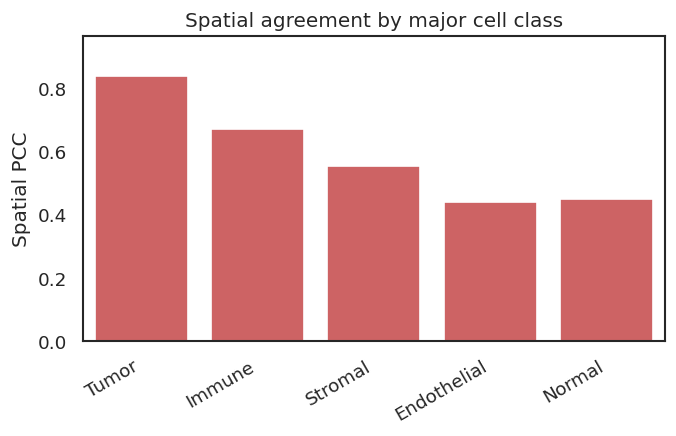

Saved: hbc1_spatial_pcc.png


major_class,spatial_pcc
Tumor,0.837100
Immune,0.670200
Stromal,0.552600
Endothelial,0.440800
Normal,0.449400


In [10]:
def softmax_scores(df, cols):
    scores = df[cols].astype(float)
    shifted = scores.sub(scores.max(axis=1), axis=0)
    exp_scores = np.exp(shifted)
    return exp_scores.div(exp_scores.sum(axis=1), axis=0).fillna(0)

score_cols_all = [f"{c}_score" for c in SEVEN_CLASSES if f"{c}_score" in phenomap_aligned.columns]
prob = softmax_scores(phenomap_aligned, score_cols_all)
prob.columns = [c.replace("_score", "") for c in prob.columns]

major_prob = pd.DataFrame(index=prob.index)
for major in MAJOR_CLASSES:
    source_classes = [k for k, v in MERGE_MAP.items() if v == major and k in prob.columns]
    major_prob[major] = prob[source_classes].sum(axis=1)

spatial_rows = []
for major in MAJOR_CLASSES:
    y_binary = (y_true_major.loc[major_prob.index] == major).astype(float)
    if y_binary.sum() == 0 or major_prob[major].std() == 0:
        pcc = np.nan
    else:
        pcc, _ = pearsonr(y_binary.values, major_prob[major].values)
    spatial_rows.append({"major_class": major, "spatial_pcc": pcc})
spatial_pcc = pd.DataFrame(spatial_rows)

pcc_path = plot_major_class_metric_bars(
    metric_df=spatial_pcc,
    metric_col="spatial_pcc",
    ylabel="Spatial PCC",
    title="Spatial agreement by major cell class",
    output_path=TUTORIAL_DIR / "hbc1_spatial_pcc.png",
    ylim=(0, max(0.05, spatial_pcc["spatial_pcc"].max() * 1.15)),
)
print(f"Saved: {pcc_path.name}")
spatial_pcc.round(4).style.hide(axis="index")